In [1]:
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import KDTree
import xarray as xr
from MHW_funcs import get_oisst_flag, get_oisst_flag_spatialONLY
from MHW_funcs import map_study_region
import matplotlib.pyplot as plt
import matplotlib.colors as mpcolors
from cmocean import cm as cmo
from cartopy import crs as ccrs
from cartopy import feature as cfeature 
import matplotlib.ticker as ticker
import boto3
import gsw
import datetime
import s3fs
import cmocean
import subprocess

BOLD = "\033[1m"
RESET = "\033[0m"
RED = "\033[31m"
LINE = "\033[4m"

# get MHW function

In [4]:
def get_crocolake_data_MHW(MHW = "SWP2023", z = 500,
                           oxygen = False, pH = False,
                           BBP = False, CHLA = False,
                           CP = False, CDOM = False, turbidity = False, 
                           DownwellingIR = False, UpwellingIR = False, DownwellingPAR = False,
                           nitrate = False, silicate = False, phosphate = False,
                           alkalinity = False, DIC = False, 
                           bad_vals = [0,3,4,6,7,9]):

    """
    Load and quality-control CrocoLake BGC-Argo data for a predefined
    marine heatwave (MHW) region and time period.

    The function identifies the geographic and temporal bounds associated
    with a selected marine heatwave event, reads CrocoLake parquet data
    within those bounds, selects requested biogeochemical variables,
    removes observations with specified QC flags, and calculates several
    derived hydrographic variables.

    Parameters
    ----------
    MHW : str, optional
        Marine heatwave event to retrieve. Default is "SWP2023".

        Recognized events include:
            - "SWP2023" : Southwest Pacific, 2023
            - "NA2023"  : North Atlantic, 2023
            - "NWP2025" : Northwest Pacific, 2025
            - "NEP2026" : Northeast Pacific, 2026

        Alternative strings containing identifying region/year
        combinations may also be recognized, such as "Pac" and "2023"
        for the Southwest Pacific event.

    z : float, optional
        Maximum pressure/depth range to retrieve, in approximately meters
        or dbar. CrocoLake observations with PRES >= z are excluded.
        Default is 500.

    oxygen : bool, optional
        If True, include dissolved oxygen (DOXY) variables.
        Default is False.

    pH : bool, optional
        If True, include pH variables.
        Default is False.

    BBP : bool, optional
        If True, include particulate backscattering (BBP) variables.
        Default is False.

    CHLA : bool, optional
        If True, include chlorophyll-a variables.
        Default is False.

    CP : bool, optional
        If True, include CP-related variables.
        Default is False.

    CDOM : bool, optional
        If True, include colored dissolved organic matter (CDOM)
        variables. Default is False.

    turbidity : bool, optional
        If True, include turbidity variables.
        Default is False.

    DownwellingIR : bool, optional
        If True, include downwelling irradiance variables identified
        by "DOWN_" in the CrocoLake variable name.
        Default is False.

    UpwellingIR : bool, optional
        If True, include upwelling irradiance variables identified
        by "UP_" in the CrocoLake variable name.
        Default is False.

    DownwellingPAR : bool, optional
        If True, include photosynthetically available radiation (PAR)
        variables. Default is False.

    nitrate : bool, optional
        If True, include nitrate variables.
        Default is False.

    silicate : bool, optional
        If True, include silicate variables.
        Default is False.

    phosphate : bool, optional
        If True, include phosphate variables.
        Default is False.

    alkalinity : bool, optional
        If True, include alkalinity variables.
        Default is False.

    DIC : bool, optional
        If True, include total dissolved inorganic carbon variables
        identified by "TCO2" in CrocoLake.
        Default is False.

    bad_vals : list of int, optional
        QC flag values considered unacceptable. Measurements associated
        with these QC flags are replaced with NaN before QC columns are
        removed. Default is [0, 3, 4, 6, 7, 9].

    Returns
    -------
    df : pandas.DataFrame
        CrocoLake observations within the selected marine heatwave
        region, time period, and pressure range.

        The dataframe always contains:
            - PLATFORM_NUMBER
            - CYCLE_NUMBER
            - LATITUDE
            - LONGITUDE
            - JULD
            - PRES
            - TEMP
            - PSAL

        Additional requested BGC variables are included depending on
        the function arguments.

        After QC, the following derived variables are also added:
            - Week   : ISO calendar week number
            - Depth  : depth calculated from pressure using TEOS-10
            - ASAL   : Absolute Salinity
            - CTEMP  : Conservative Temperature
            - sigma0 : potential density anomaly referenced to 0 dbar

    mhw_info : pandas.DataFrame
        One-row dataframe containing the geographic, vertical, and
        temporal bounds used for the selected marine heatwave event.
        Columns are:
            - Name
            - lat0
            - lat1
            - lon0
            - lon1
            - z0
            - z1
            - date0
            - date1

    Notes
    -----
    CrocoLake data are read from the shared parquet dataset located at:

        /home/jovyan/shared/go-bgc-2026/data/CrocoLake/BGC_CROCOLAKE/

    If the selected longitude range crosses the 180-degree meridian,
    the region is divided into two longitude ranges and the resulting
    datasets are concatenated.

    Variable selection is based on substrings in CrocoLake column names.
    Corresponding *_QC variables are retained temporarily so that
    observations with QC flags listed in `bad_vals` can be replaced
    with NaN. QC columns are then removed.

    All columns except JULD are converted to float64 where possible.
    Values that cannot be converted numerically are replaced with NaN.

    Depth is calculated using `gsw.z_from_p`. TEOS-10 uses the convention
    that z is negative below sea level, so the returned `Depth` values
    are generally negative downward.

    Absolute Salinity, Conservative Temperature, and sigma0 are
    calculated using the Gibbs SeaWater (gsw) toolbox.

    References
    ----------
    CrocoLake documentation:
    https://crocolakedocs.readthedocs.io/en/latest/crocolake.html
    """
    # --------------
    # Identify MHW
    # --------------
    # Southwest Pacific 2023
    if "SWP" in MHW or ("Pac" in MHW and "2023" in MHW):
        print("Southwest Pacific 2023 chosen.")
        lat0 = -60
        lat1 = -40 
        lon0 = 150 
        lon1 = -140
        z0 = 0
        z1 = z
        date0 = pd.to_datetime("2022-11-17")
        date1 = pd.to_datetime("2024-01-01")
    # North Atlantic 2023
    elif ("NA" in MHW or "Atl" in MHW) and "2023" in MHW:
        print("North Atlantic 2023 chosen.")
        lat0 = 10
        lat1 = 60 
        lon0 = -60 
        lon1 = -10
        z0 = 0
        z1 = z
        date0 = pd.to_datetime("2022-10-01")
        date1 = pd.to_datetime("2024-06-01")
    # Northwest Pacific 2025
    elif("NWP" in MHW or "Pac" in MHW) and "2025" in MHW:
        print("Northwest Pacific 2025 chosen.")
        lat0 = 15
        lat1 = 55 
        lon0 = 130 
        lon1 = 180
        z0 = 0
        z1 = z
        date0 = pd.to_datetime("2025-05-01")
        date1 = pd.to_datetime("2026-08-01")
    # Northeast Pacific 2026
    elif("NEP" in MHW or "Pac" in MHW) and "2026" in MHW:
        print("Northeast Pacific 2026 chosen.")
        lat0 = 10
        lat1 = 35 
        lon0 = -150 
        lon1 = -100
        z0 = 0
        z1 = z
        date0 = pd.to_datetime("2025-09-01")
        date1 = pd.to_datetime("2026-07-01")
    else:
        print("Choose from the following: Southwest Pacific 2023, North Atlantic 2023, Northwest Pacific 2025, or Northeast Pacific 2026")
        return

    # Output bounds of MHW
    temp = {"Name": [MHW], 
            "lat0": [lat0], 
            "lat1": [lat1], 
            "lon0": [lon0], 
            "lon1": [lon1],
            "z0": [z0], 
            "z1": [z1], 
            "date0": [date0], 
            "date1": [date1]}
    mhw_info = pd.DataFrame(temp)
    del temp

    # --------------
    # Get Crocolake data
    # https://crocolakedocs.readthedocs.io/en/latest/crocolake.html
    # --------------
    
    # Directories (may need to be updated)
    parquet_dir = '/home/jovyan/shared/go-bgc-2026/data/CrocoLake/BGC_CROCOLAKE/'
    BGC_schema = pq.read_schema(parquet_dir+"_common_metadata")

    # If lon crosses 180deg
    if lon0 > lon1:
        # First half of meridional domain
        filters1 = [
                    ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                    ("LONGITUDE",">",lon0), ("LONGITUDE","<=",180),
                    ("JULD",">",date0), ("JULD","<",date1),
                    ("PRES","<",z1), #("PRES",">=",z0),
                    # ("DB_NAME","=","ARGO") 
                    ]
        df1 = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters1)
        df1 = df1.read().to_pandas()
    
        # Second half of meridional domain
        filters2 = [
                    ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                    ("LONGITUDE",">",-180), ("LONGITUDE","<=",lon1),
                    ("JULD",">",date0), ("JULD","<",date1),
                    ("PRES","<",z1), #("PRES",">=",z0),
                    # ("DB_NAME","=","ARGO") 
                    ]
        df2 = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters2)
        df2 = df2.read().to_pandas()
    
        # Combine domains
        df = pd.concat([df1, df2], ignore_index=True)
    
    # If lon does NOT cross 180deg (normal case)
    else:
        filters = [
                    ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                    ("LONGITUDE",">",lon0), ("LONGITUDE","<",lon1),
                    ("JULD",">",date0), ("JULD","<",date1),
                    ("PRES","<",z1), #("PRES",">",z0),
                    # ("DB_NAME","=","ARGO") 
                    ]
        df = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters)
        df = df.read().to_pandas()

    # --------------
    # Select Crocolake data
    # https://crocolakedocs.readthedocs.io/en/latest/crocolake.html
    # --------------
    
    base_info = ['PLATFORM_NUMBER', 'CYCLE_NUMBER', 'LATITUDE', 'LONGITUDE', 'JULD', 
                 'PRES', 'TEMP', 'PSAL']
    oxygen_info = [item for item in list(df.keys()) if "DOXY" in item and "DATA_MODE" not in item]
    bbp_info = [item for item in list(df.keys()) if "BBP" in item and "DATA_MODE" not in item]
    chla_info = [item for item in list(df.keys()) if "CHL" in item and "DATA_MODE" not in item]
    downirrad_info = [item for item in list(df.keys()) if "DOWN_" in item and "DATA_MODE" not in item]
    ph_info = [item for item in list(df.keys()) if "PH_" in item and "DATA_MODE" not in item]
    nitrate_info = [item for item in list(df.keys()) if "NITR" in item and "DATA_MODE" not in item]
    cp_info = [item for item in list(df.keys()) if "CP" in item and "DATA_MODE" not in item]
    turbidity_info = [item for item in list(df.keys()) if "TURB" in item and "DATA_MODE" not in item]
    upirrad_info = [item for item in list(df.keys()) if "UP_" in item and "DATA_MODE" not in item]
    downpar_info = [item for item in list(df.keys()) if "PAR" in item and "DATA_MODE" not in item]
    tco2_info = [item for item in list(df.keys()) if "TCO2" in item and "DATA_MODE" not in item]
    alk_info = [item for item in list(df.keys()) if "ALK" in item and "DATA_MODE" not in item]
    silicate_info = [item for item in list(df.keys()) if "SIL" in item and "DATA_MODE" not in item]
    phosphate_info = [item for item in list(df.keys()) if "PHOS" in item and "DATA_MODE" not in item]
    cdom_info = [item for item in list(df.keys()) if "CDOM" in item and "DATA_MODE" not in item]

    params = base_info

    if oxygen:
        params = params + oxygen_info
    if BBP:
        params = params + bbp_info
    if turbidity:
        params = params + turbidity_info
    if CHLA:
        params = params + chla_info
    if CP:
        params = params + cp_info
    if CDOM:
        params = params + cdom_info
    if nitrate:
        params = params + nitrate_info
    if silicate:
        params = params + silicate_info
    if phosphate:
        params = params + phosphate_info
    if pH:
        params = params + ph_info
    if alkalinity:
        params = params + alk_info
    if DIC:
        params = params + tco2_info
    if DownwellingIR:
        params = params + downirrad_info
    if UpwellingIR:
        params = params + upirrad_info
    if DownwellingPAR:
        params = params + downpar_info

    df = df.loc[:,params]

    # --------------
    # Filter out bad data
    # --------------

    qc_strings = [s for s in params if s.endswith("QC")]

    for s in qc_strings:
        var = s.removesuffix("_QC")
        df.loc[df[s].isin(bad_vals), var] = np.nan

    for col in params:
        if col != 'JULD':
            df[col] = pd.to_numeric(df[col], errors='coerce').astype('float64')
    df = df.drop(columns=[col for col in df.columns if col.endswith('_QC')])
    print(f"You have selected the following parameters after QC: {list(df.keys())}")

    # --------------
    # Add more variables: week number, depth, absolute salinity, conservative temperature, density
    # --------------
    df['Week'] = df['JULD'].dt.isocalendar().week
    df['Depth'] = gsw.z_from_p(df['PRES'], df['LATITUDE'])
    df['ASAL'] = gsw.SA_from_SP(df['PSAL'], df['PRES'], df['LONGITUDE'], df['LATITUDE'])
    df['CTEMP'] = gsw.CT_from_t(df['ASAL'], df['TEMP'], df['PRES'])
    df['sigma0'] = gsw.sigma0(df['ASAL'], df['CTEMP'])

    return df, mhw_info
        

# get climatology function

In [5]:
def get_crocolake_data_climatology(MHW = "SWP2023", z = 500,
                                   oxygen = False, pH = False,
                                   BBP = False, CHLA = False,
                                   CP = False, CDOM = False, turbidity = False, 
                                   DownwellingIR = False, UpwellingIR = False, DownwellingPAR = False,
                                   nitrate = False, silicate = False, phosphate = False,
                                   alkalinity = False, DIC = False, 
                                   bad_vals = [0,3,4,6,7,9]):

    """
    Load and quality-control CrocoLake BGC-Argo data for climatology for 
    a predefined marine heatwave (MHW) region and time period.

    The function identifies the geographic and temporal bounds associated
    with a selected marine heatwave event, reads CrocoLake parquet data
    within those spatial bounds and outside of those temporal bounds, 
    selects requested biogeochemical variables,
    removes observations with specified QC flags, and calculates several
    derived hydrographic variables.

    Parameters
    ----------
    MHW : str, optional
        Marine heatwave event to retrieve. Default is "SWP2023".

        Recognized events include:
            - "SWP2023" : Southwest Pacific, 2023
            - "NA2023"  : North Atlantic, 2023
            - "NWP2025" : Northwest Pacific, 2025
            - "NEP2026" : Northeast Pacific, 2026

        Alternative strings containing identifying region/year
        combinations may also be recognized, such as "Pac" and "2023"
        for the Southwest Pacific event.

    z : float, optional
        Maximum pressure/depth range to retrieve, in approximately meters
        or dbar. CrocoLake observations with PRES >= z are excluded.
        Default is 500.

    oxygen : bool, optional
        If True, include dissolved oxygen (DOXY) variables.
        Default is False.

    pH : bool, optional
        If True, include pH variables.
        Default is False.

    BBP : bool, optional
        If True, include particulate backscattering (BBP) variables.
        Default is False.

    CHLA : bool, optional
        If True, include chlorophyll-a variables.
        Default is False.

    CP : bool, optional
        If True, include CP-related variables.
        Default is False.

    CDOM : bool, optional
        If True, include colored dissolved organic matter (CDOM)
        variables. Default is False.

    turbidity : bool, optional
        If True, include turbidity variables.
        Default is False.

    DownwellingIR : bool, optional
        If True, include downwelling irradiance variables identified
        by "DOWN_" in the CrocoLake variable name.
        Default is False.

    UpwellingIR : bool, optional
        If True, include upwelling irradiance variables identified
        by "UP_" in the CrocoLake variable name.
        Default is False.

    DownwellingPAR : bool, optional
        If True, include photosynthetically available radiation (PAR)
        variables. Default is False.

    nitrate : bool, optional
        If True, include nitrate variables.
        Default is False.

    silicate : bool, optional
        If True, include silicate variables.
        Default is False.

    phosphate : bool, optional
        If True, include phosphate variables.
        Default is False.

    alkalinity : bool, optional
        If True, include alkalinity variables.
        Default is False.

    DIC : bool, optional
        If True, include total dissolved inorganic carbon variables
        identified by "TCO2" in CrocoLake.
        Default is False.

    bad_vals : list of int, optional
        QC flag values considered unacceptable. Measurements associated
        with these QC flags are replaced with NaN before QC columns are
        removed. Default is [0, 3, 4, 6, 7, 9].

    Returns
    -------
    df : pandas.DataFrame
        CrocoLake observations within the selected marine heatwave
        region, time period, and pressure range.

        The dataframe always contains:
            - PLATFORM_NUMBER
            - CYCLE_NUMBER
            - LATITUDE
            - LONGITUDE
            - JULD
            - PRES
            - TEMP
            - PSAL

        Additional requested BGC variables are included depending on
        the function arguments.

        After QC, the following derived variables are also added:
            - Week   : ISO calendar week number
            - Depth  : depth calculated from pressure using TEOS-10
            - ASAL   : Absolute Salinity
            - CTEMP  : Conservative Temperature
            - sigma0 : potential density anomaly referenced to 0 dbar

    mhw_info : pandas.DataFrame
        One-row dataframe containing the geographic, vertical, and
        temporal bounds used for the selected marine heatwave event.
        Columns are:
            - Name
            - lat0
            - lat1
            - lon0
            - lon1
            - z0
            - z1
            - date0
            - date1

    Notes
    -----
    CrocoLake data are read from the shared parquet dataset located at:

        /home/jovyan/shared/go-bgc-2026/data/CrocoLake/BGC_CROCOLAKE/

    If the selected longitude range crosses the 180-degree meridian,
    the region is divided into two longitude ranges and the resulting
    datasets are concatenated.

    Variable selection is based on substrings in CrocoLake column names.
    Corresponding *_QC variables are retained temporarily so that
    observations with QC flags listed in `bad_vals` can be replaced
    with NaN. QC columns are then removed.

    All columns except JULD are converted to float64 where possible.
    Values that cannot be converted numerically are replaced with NaN.

    Depth is calculated using `gsw.z_from_p`. TEOS-10 uses the convention
    that z is negative below sea level, so the returned `Depth` values
    are generally negative downward.

    Absolute Salinity, Conservative Temperature, and sigma0 are
    calculated using the Gibbs SeaWater (gsw) toolbox.

    References
    ----------
    CrocoLake documentation:
    https://crocolakedocs.readthedocs.io/en/latest/crocolake.html
    """
    # --------------
    # Identify MHW
    # --------------
    # Southwest Pacific 2023
    if "SWP" in MHW or ("Pac" in MHW and "2023" in MHW):
        print("Southwest Pacific 2023 chosen.")
        lat0 = -60
        lat1 = -40 
        lon0 = 150 
        lon1 = -140
        z0 = 0
        z1 = z
        date0 = pd.to_datetime("2022-11-17")
        date1 = pd.to_datetime("2024-01-01")
    # North Atlantic 2023
    elif ("NA" in MHW or "Atl" in MHW) and "2023" in MHW:
        print("North Atlantic 2023 chosen.")
        lat0 = 10
        lat1 = 60 
        lon0 = -60 
        lon1 = -10
        z0 = 0
        z1 = z
        date0 = pd.to_datetime("2022-10-01")
        date1 = pd.to_datetime("2024-06-01")
    # Northwest Pacific 2025
    elif("NWP" in MHW or "Pac" in MHW) and "2025" in MHW:
        print("Northwest Pacific 2025 chosen.")
        lat0 = 15
        lat1 = 55 
        lon0 = 130 
        lon1 = 180
        z0 = 0
        z1 = z
        date0 = pd.to_datetime("2025-05-01")
        date1 = pd.to_datetime("2026-08-01")
    # Northeast Pacific 2026
    elif("NEP" in MHW or "Pac" in MHW) and "2026" in MHW:
        print("Northeast Pacific 2026 chosen.")
        lat0 = 10
        lat1 = 35 
        lon0 = -150 
        lon1 = -100
        z0 = 0
        z1 = z
        date0 = pd.to_datetime("2025-09-01")
        date1 = pd.to_datetime("2026-07-01")
    else:
        print("Choose from the following: Southwest Pacific 2023, North Atlantic 2023, Northwest Pacific 2025, or Northeast Pacific 2026")
        return

    # Output bounds of MHW
    temp = {"Name": [MHW], 
            "lat0": [lat0], 
            "lat1": [lat1], 
            "lon0": [lon0], 
            "lon1": [lon1],
            "z0": [z0], 
            "z1": [z1], 
            "date0": [date0], 
            "date1": [date1]}
    mhw_info = pd.DataFrame(temp)
    del temp

    # --------------
    # Get Crocolake data
    # https://crocolakedocs.readthedocs.io/en/latest/crocolake.html
    # --------------
    
    # Directories (may need to be updated)
    parquet_dir = '/home/jovyan/shared/go-bgc-2026/data/CrocoLake/BGC_CROCOLAKE/'
    BGC_schema = pq.read_schema(parquet_dir+"_common_metadata")

    # *********************
    # BEFORE
    # *********************
    # If lon crosses 180deg
    if lon0 > lon1:
        # First half of meridional domain
        filters1 = [
                    ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                    ("LONGITUDE",">",lon0), ("LONGITUDE","<=",180),
                    ("JULD","<",date0), 
                    ("PRES","<",z1), #("PRES",">=",z0),
                    # ("DB_NAME","=","ARGO") 
                    ]
        df1 = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters1)
        df1 = df1.read().to_pandas()
    
        # Second half of meridional domain
        filters2 = [
                    ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                    ("LONGITUDE",">",-180), ("LONGITUDE","<=",lon1),
                    ("JULD","<",date0), 
                    ("PRES","<",z1), #("PRES",">=",z0),
                    # ("DB_NAME","=","ARGO") 
                    ]
        df2 = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters2)
        df2 = df2.read().to_pandas()
    
        # Combine domains
        df_before = pd.concat([df1, df2], ignore_index=True)
    
    # If lon does NOT cross 180deg (normal case)
    else:
        filters = [
                    ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                    ("LONGITUDE",">",lon0), ("LONGITUDE","<",lon1),
                    ("JULD","<",date0),
                    ("PRES","<",z1), #("PRES",">",z0),
                    # ("DB_NAME","=","ARGO") 
                    ]
        df_before = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters)
        df_before = df_before.read().to_pandas()

    # *********************
    # AFTER
    # *********************
    # If lon crosses 180deg
    if lon0 > lon1:
        # First half of meridional domain
        filters1 = [
                    ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                    ("LONGITUDE",">",lon0), ("LONGITUDE","<=",180),
                    ("JULD",">",date0), 
                    ("PRES","<",z1), #("PRES",">=",z0),
                    # ("DB_NAME","=","ARGO") 
                    ]
        df1 = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters1)
        df1 = df1.read().to_pandas()
    
        # Second half of meridional domain
        filters2 = [
                    ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                    ("LONGITUDE",">",-180), ("LONGITUDE","<=",lon1),
                    ("JULD",">",date0), 
                    ("PRES","<",z1), #("PRES",">=",z0),
                    # ("DB_NAME","=","ARGO") 
                    ]
        df2 = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters2)
        df2 = df2.read().to_pandas()
    
        # Combine domains
        df_after = pd.concat([df1, df2], ignore_index=True)
    
    # If lon does NOT cross 180deg (normal case)
    else:
        filters = [
                    ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                    ("LONGITUDE",">",lon0), ("LONGITUDE","<",lon1),
                    ("JULD",">",date0),
                    ("PRES","<",z1), #("PRES",">",z0),
                    # ("DB_NAME","=","ARGO") 
                    ]
        df_after = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters)
        df_after = df_after.read().to_pandas()

    # ******************************
    # COMBINE BEFORE & AFTER
    # ******************************
    
    df = pd.concat([df_before, df_after], ignore_index=True)

    # --------------
    # Select Crocolake data
    # https://crocolakedocs.readthedocs.io/en/latest/crocolake.html
    # --------------
    
    base_info = ['PLATFORM_NUMBER', 'CYCLE_NUMBER', 'LATITUDE', 'LONGITUDE', 'JULD', 
                 'PRES', 'TEMP', 'PSAL']
    oxygen_info = [item for item in list(df.keys()) if "DOXY" in item and "DATA_MODE" not in item]
    bbp_info = [item for item in list(df.keys()) if "BBP" in item and "DATA_MODE" not in item]
    chla_info = [item for item in list(df.keys()) if "CHL" in item and "DATA_MODE" not in item]
    downirrad_info = [item for item in list(df.keys()) if "DOWN_" in item and "DATA_MODE" not in item]
    ph_info = [item for item in list(df.keys()) if "PH" in item and "DATA_MODE" not in item]
    nitrate_info = [item for item in list(df.keys()) if "NITR" in item and "DATA_MODE" not in item]
    cp_info = [item for item in list(df.keys()) if "CP" in item and "DATA_MODE" not in item]
    turbidity_info = [item for item in list(df.keys()) if "TURB" in item and "DATA_MODE" not in item]
    upirrad_info = [item for item in list(df.keys()) if "UP_" in item and "DATA_MODE" not in item]
    downpar_info = [item for item in list(df.keys()) if "PAR" in item and "DATA_MODE" not in item]
    tco2_info = [item for item in list(df.keys()) if "TCO2" in item and "DATA_MODE" not in item]
    alk_info = [item for item in list(df.keys()) if "ALK" in item and "DATA_MODE" not in item]
    silicate_info = [item for item in list(df.keys()) if "SIL" in item and "DATA_MODE" not in item]
    phosphate_info = [item for item in list(df.keys()) if "PHOS" in item and "DATA_MODE" not in item]
    cdom_info = [item for item in list(df.keys()) if "CDOM" in item and "DATA_MODE" not in item]

    params = base_info

    if oxygen:
        params = params + oxygen_info
    if BBP:
        params = params + bbp_info
    if turbidity:
        params = params + turbidity_info
    if CHLA:
        params = params + chla_info
    if CP:
        params = params + cp_info
    if CDOM:
        params = params + cdom_info
    if nitrate:
        params = params + nitrate_info
    if silicate:
        params = params + silicate_info
    if phosphate:
        params = params + phosphate_info
    if pH:
        params = params + ph_info
    if alkalinity:
        params = params + alk_info
    if DIC:
        params = params + tco2_info
    if DownwellingIR:
        params = params + downirrad_info
    if UpwellingIR:
        params = params + upirrad_info
    if DownwellingPAR:
        params = params + downpar_info

    df = df.loc[:,params]

    # --------------
    # Filter out bad data
    # --------------

    qc_strings = [s for s in params if s.endswith("QC")]

    for s in qc_strings:
        var = s.removesuffix("_QC")
        df.loc[df[s].isin(bad_vals), var] = np.nan

    for col in params:
        if col != 'JULD':
            df[col] = pd.to_numeric(df[col], errors='coerce').astype('float64')
    df = df.drop(columns=[col for col in df.columns if col.endswith('_QC')])
    print(f"You have selected the following parameters after QC: {list(df.keys())}")

    # --------------
    # Add more variables: week number, depth, absolute salinity, conservative temperature, density
    # --------------
    df['Week'] = df['JULD'].dt.isocalendar().week
    df['Depth'] = gsw.z_from_p(df['PRES'], df['LATITUDE'])
    df['ASAL'] = gsw.SA_from_SP(df['PSAL'], df['PRES'], df['LONGITUDE'], df['LATITUDE'])
    df['CTEMP'] = gsw.CT_from_t(df['ASAL'], df['TEMP'], df['PRES'])
    df['sigma0'] = gsw.sigma0(df['ASAL'], df['CTEMP'])

    return df, mhw_info
        

# despike function

In [6]:
def despike(df, 
            BBP_SMOOTH_MODE = "cornec",
            CHL_MEDIAN_WINDOW = 7,
            BBP_MEDIAN_WINDOW = 5,
            BBP_MEAN_WINDOW = 5,
            DCM_MEDIAN_WINDOW = 5):

    """Vertical despiking on the native profile resolution.

    Based on function written by Clara Vives: 
        - https://github.com/go-bgc/Marine-Heat-Waves/tree/main/contributors/Clara

    chl gets a 7-point running median (Su et al. 2021, https://doi.org/10.1016/j.jmarsys.2021.103569,
    as used by Vives et al. 2025 Sect. 2.1.1). bbp gets the Cornec, Claustre et al. (2021) filter — a
    5-point running median followed by a 5-point running mean — because bbp
    carries sharp particle-aggregate spikes that a median alone leaves a step
    at. Both are centred with min_periods=1, so the top and bottom of a profile
    survive instead of turning into NaN.

    Profiles are sorted by PRES first: a running filter over unsorted levels is
    meaningless, and Sprof level order is not guaranteed.
    """
    df = df.sort_values(["PLATFORM_NUMBER", "CYCLE_NUMBER", "PRES"]).copy()
    grouped = df.groupby(["PLATFORM_NUMBER", "CYCLE_NUMBER"], sort=False)

    if "CHLA" in df.keys():
        
        df["CHLA_RAW"] = df["CHLA"]
        df["CHLA"] = grouped["CHLA"].transform(
        lambda s: s.rolling(CHL_MEDIAN_WINDOW, center=True, min_periods=1).median())

    if "BBP700" in df.keys():
        df["BBP700_RAW"] = df["BBP700"]
    
        if BBP_SMOOTH_MODE == "cornec":
            med = grouped["BBP700"].transform(
                lambda s: s.rolling(BBP_MEDIAN_WINDOW, center=True, min_periods=1).median())
            df["BBP700"] = med
            df["BBP700"] = df.groupby(["PLATFORM_NUMBER", "CYCLE_NUMBER"], sort=False)["BBP700"].transform(
                lambda s: s.rolling(BBP_MEAN_WINDOW, center=True, min_periods=1).mean())
        else:
            df["BBP700"] = grouped["BBP700"].transform(
                lambda s: s.rolling(CHL_MEDIAN_WINDOW, center=True, min_periods=1).median())

    if "BBP470" in df.keys():
        df["BBP470_RAW"] = df["BBP470"]
    
        if BBP_SMOOTH_MODE == "cornec":
            med = grouped["BBP470"].transform(
                lambda s: s.rolling(BBP_MEDIAN_WINDOW, center=True, min_periods=1).median())
            df["BBP470"] = med
            df["BBP470"] = df.groupby(["PLATFORM_NUMBER", "CYCLE_NUMBER"], sort=False)["BBP470"].transform(
                lambda s: s.rolling(BBP_MEAN_WINDOW, center=True, min_periods=1).mean())
        else:
            df["BBP470"] = grouped["BBP470"].transform(
                lambda s: s.rolling(CHL_MEDIAN_WINDOW, center=True, min_periods=1).median())

    if "BBP532" in df.keys():
        df["BBP532_RAW"] = df["BBP532"]
    
        if BBP_SMOOTH_MODE == "cornec":
            med = grouped["BBP532"].transform(
                lambda s: s.rolling(BBP_MEDIAN_WINDOW, center=True, min_periods=1).median())
            df["BBP532"] = med
            df["BBP532"] = df.groupby(["PLATFORM_NUMBER", "CYCLE_NUMBER"], sort=False)["BBP532"].transform(
                lambda s: s.rolling(BBP_MEAN_WINDOW, center=True, min_periods=1).mean())
        else:
            df["BBP532"] = grouped["BBP532"].transform(
                lambda s: s.rolling(CHL_MEDIAN_WINDOW, center=True, min_periods=1).median())
    return df

# profile qc functions

In [8]:
def profile_coverage_qc_chl_bbp(df, FIRST_PRES_MAX = 10.0, MIN_OBS_300 = 20, INTERP_MAX = 500.0):
    """Drop whole profiles that are too sparse to integrate (Vives et al. 2025).

    (a) the shallowest pressure must be in the upper FIRST_PRES_MAX m, and
    (b) the upper 300 m must carry at least MIN_OBS_300 observations of BOTH
        chl and bbp.
    Returns (kept, report) so the caller can print how many went and why.

    Based on function written by Clara Vives: 
        - https://github.com/go-bgc/Marine-Heat-Waves/tree/main/contributors/Clara
    """

    keys = ["PLATFORM_NUMBER", "CYCLE_NUMBER"]
    upper = df[df["PRES"] <= INTERP_MAX]
    stats = upper.groupby(keys).agg(
        first_pres=("PRES", "min"),
        n_chl=("CHLA", "count"),
        n_bbp=("BBP700", "count"))

    shallow_ok = stats["first_pres"] <= FIRST_PRES_MAX
    count_ok = (stats["n_chl"] >= MIN_OBS_300) & (stats["n_bbp"] >= MIN_OBS_300)
    good = stats.index[shallow_ok & count_ok]

    report = dict(n_profiles=len(stats),
                  fail_first_pres=int((~shallow_ok).sum()),
                  fail_n_obs=int((~count_ok).sum()),
                  kept=len(good))
    kept = df.set_index(keys).loc[good].reset_index()
    return kept, report

In [10]:
def profile_coverage_qc(
    df,
    variables,
    FIRST_PRES_MAX=10.0,
    COUNT_PRES_MAX=300.0,
    MIN_OBS=20
):
    """
    Drop whole profiles that are too sparse for analysis.

    A profile is retained if:
      (a) the shallowest pressure is <= FIRST_PRES_MAX, and
      (b) each variable in `variables` has at least MIN_OBS valid
          observations within the upper COUNT_PRES_MAX dbar.

    Returns
    -------
    kept : pandas.DataFrame
        Profiles passing QC.

    report : dict
        Summary of QC failures.
    """

    keys = ["PLATFORM_NUMBER", "CYCLE_NUMBER"]

    # Only use the upper portion of each profile for the observation-count QC
    upper = df[df["PRES"] <= COUNT_PRES_MAX]

    # Build aggregation dynamically
    agg_dict = {
        "first_pres": ("PRES", "min")
    }

    for var in variables:
        agg_dict[f"n_{var}"] = (var, "count")

    stats = upper.groupby(keys).agg(**agg_dict)

    # -------------------------
    # QC conditions
    # -------------------------

    shallow_ok = stats["first_pres"] <= FIRST_PRES_MAX

    count_cols = [f"n_{var}" for var in variables]

    count_ok = (
        stats[count_cols] >= MIN_OBS
    ).all(axis=1)

    good = stats.index[shallow_ok & count_ok]

    # -------------------------
    # QC report
    # -------------------------

    report = {
        "n_profiles": len(stats),
        "fail_first_pres": int((~shallow_ok).sum()),
        "fail_n_obs_any_variable": int((~count_ok).sum()),
        "kept": len(good)
    }

    # Report failures by variable
    for var in variables:
        report[f"fail_{var}"] = int(
            (stats[f"n_{var}"] < MIN_OBS).sum()
        )

    # Keep entire profile, not just upper 300 m
    kept = (
        df.set_index(keys)
        .loc[good]
        .reset_index()
    )

    return kept, report

# regrid function

In [12]:
def regrid_1m(df, INTERP_DZ = 1.0, INTERP_MAX = 500.0, 
              DCM_MEDIAN_WINDOW = 5,
              BBP_MEDIAN_WINDOW = 5,
              BBP_MEAN_WINDOW = 5):
    """Extrapolate each profile to the surface, then interpolate chl and bbp to
    a 1 m grid from 0 to 300 m (Vives et al. 2025, Sect. 2.1).

    The surface extrapolation is constant, not linear: the shallowest good
    value is carried up to 0 m. Extrapolating a gradient through the top few
    metres of a fluorescence profile invents a quenching signal that is not in
    the data.

    Two extra fields are built ON this grid, kept separate from the analysis
    fields exactly as the paper separates them, for later DCM/DBM work:
      CHLA_DCM   5-point running median
      BBP700_DBM 5-point running median then 5-point running mean

    Based on function written by Clara Vives: 
        - https://github.com/go-bgc/Marine-Heat-Waves/tree/main/contributors/Clara
    """

    # 1 m regrid, Vives et al. (2025) Sect. 2.1
    INTERP_GRID = np.arange(0.0, INTERP_MAX + INTERP_DZ, INTERP_DZ)
    
    keys = ["PLATFORM_NUMBER", "CYCLE_NUMBER"]
    meta_cols = ["JULD", "LATITUDE", "LONGITUDE"]
    out = []
    for (wmo, cycle), prof in df.groupby(keys, sort=False):
        prof = prof.sort_values("PRES")
        rec = {"PLATFORM_NUMBER": wmo, "CYCLE_NUMBER": cycle, "PRES": INTERP_GRID}

        # Don't interpolate these columns
        no_interp = ['PLATFORM_NUMBER', 'CYCLE_NUMBER', 'LATITUDE', 'LONGITUDE', 'JULD',
                     'PRES', 'Week', 'Depth', 'sigma0']
        # List out all the columns that can be interpolate
        COLS = [item for item in list(df.keys()) if item not in no_interp and "_ERROR" not in item]

        # Do the interpolating
        for col in COLS:
            good = prof.dropna(subset=[col])
            if len(good) < 2:
                rec[col] = np.full(INTERP_GRID.shape, np.nan)
                continue
            z, v = good["PRES"].values, good[col].values
            # np.interp holds the end values flat outside the data range, which
            # is exactly the constant surface extrapolation we want
            interp = np.interp(INTERP_GRID, z, v)
            interp[INTERP_GRID > z[-1]] = np.nan      # never extrapolate downward
            rec[col] = interp
        block = pd.DataFrame(rec)
        for col in meta_cols:
            block[col] = prof[col].iloc[0]
        out.append(block)

    grid = pd.concat(out, ignore_index=True)
    grouped = grid.groupby(keys, sort=False)
    grid["CHLA_DCM"] = grouped["CHLA"].transform(
        lambda s: s.rolling(DCM_MEDIAN_WINDOW, center=True, min_periods=1).median())
    bbp_med = grouped["BBP700"].transform(
        lambda s: s.rolling(BBP_MEDIAN_WINDOW, center=True, min_periods=1).median())
    grid["BBP700_DBM"] = bbp_med
    grid["BBP700_DBM"] = grid.groupby(keys, sort=False)["BBP700_DBM"].transform(
        lambda s: s.rolling(BBP_MEAN_WINDOW, center=True, min_periods=1).mean())

    # Add back in variables that could not be interpolated
    grid['Week'] = grid['JULD'].dt.isocalendar().week
    grid['Depth'] = gsw.z_from_p(grid['PRES'], grid['LATITUDE'])
    grid['sigma0'] = gsw.sigma0(grid['ASAL'], grid['CTEMP'])
    return grid

# profile averaging function

In [13]:
def average_across_profiles(df):

    """
    Average observations across profiles for each date and pressure level.

    Groups the dataframe by sampling date/time (`JULD`) and pressure (`PRES`)
    and calculates the mean of all numeric variables within each group. This
    produces a single mean observation for each unique JULD-PRES combination.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe containing `JULD`, `PRES`, and one or more numeric
        variables to average.

    Returns
    -------
    pandas.DataFrame
        Dataframe containing one row for each unique combination of `JULD`
        and `PRES`, with numeric variables averaged across observations.

    Notes
    -----
    This function is useful when multiple profiles or platforms have
    observations at the same date/time and pressure and a single average
    profile is desired.

    Non-numeric columns that are not part of the grouping may cause issues
    depending on the pandas version and should generally be removed before
    applying this function.
    """

    df = df.groupby(by = ['JULD', 'PRES']).mean().reset_index()

    return df

# it's data time

In [31]:
# Get data
df_mhw, mhw_info = get_crocolake_data_MHW(MHW = "SWP2023", z = 500, CHLA = True, BBP = True, 
                                          nitrate = True, oxygen = True, pH = True)
df_clim, mhw_info = get_crocolake_data_climatology(MHW = "SWP2023", z = 500, CHLA = True, BBP = True, 
                                                   nitrate = True, oxygen = True, pH = True)

# Despike
df_mhw = despike(df_mhw)
df_clim = despike(df_clim)

# Profile QC
df_mhw, report = profile_coverage_qc(df_mhw,
                                     variables=[
                                         "CHLA",
                                         "BBP700",
                                         "NITRATE",
                                         "DOXY",
                                         "PH_IN_SITU_TOTAL",
                                     ])
df_clim, report = profile_coverage_qc(df_clim,
                                      variables=[
                                          "CHLA",
                                          "BBP700",
                                          "NITRATE",
                                          "DOXY",
                                          "PH_IN_SITU_TOTAL",
                                      ])

# Regrid
df_mhw = regrid_1m(df_mhw)
df_clim = regrid_1m(df_clim)

# Averaging
df_mhw = average_across_profiles(df_mhw)
df_clim = average_across_profiles(df_clim)

Southwest Pacific 2023 chosen.


You have selected the following parameters after QC: ['PLATFORM_NUMBER', 'CYCLE_NUMBER', 'LATITUDE', 'LONGITUDE', 'JULD', 'PRES', 'TEMP', 'PSAL', 'DOXY', 'DOXY_ERROR', 'BBP', 'BBP_ERROR', 'BBP470', 'BBP470_ERROR', 'BBP532', 'BBP532_ERROR', 'BBP700', 'BBP700_ERROR', 'CHLA', 'CHLA_ERROR', 'NITRATE', 'NITRATE_ERROR', 'PH_IN_SITU_TOTAL', 'PH_IN_SITU_TOTAL_ERROR']


Southwest Pacific 2023 chosen.


You have selected the following parameters after QC: ['PLATFORM_NUMBER', 'CYCLE_NUMBER', 'LATITUDE', 'LONGITUDE', 'JULD', 'PRES', 'TEMP', 'PSAL', 'DOXY', 'DOXY_ERROR', 'BBP', 'BBP_ERROR', 'BBP470', 'BBP470_ERROR', 'BBP532', 'BBP532_ERROR', 'BBP700', 'BBP700_ERROR', 'CHLA', 'CHLA_ERROR', 'NITRATE', 'NITRATE_ERROR', 'PH_IN_SITU_TOTAL', 'PH_IN_SITU_TOTAL_ERROR', 'PHOSPHATE', 'PHOSPHATE_ERROR']


# MLD and nitracline functions

In [15]:
def get_density_threshold_depth(group, delta_sigma=0.03):
    
    # Sort shallowest -> deepest
    group = group.sort_values('Depth', ascending=False)
    
    # Remove missing values
    group = group.dropna(subset=['Depth', 'sigma0'])
    
    if group.empty:
        return np.nan

    # sigma0 at shallowest depth in THIS profile
    shallow_sigma = group['sigma0'].iloc[0]
    
    # Target density
    target_sigma = shallow_sigma + delta_sigma
    
    # Measurements meeting/exceeding target
    hits = group[group['sigma0'] >= target_sigma]
    
    if hits.empty:
        return np.nan
    
    # First depth where density crosses threshold
    return hits['Depth'].iloc[0]

In [16]:
def get_nitrate_threshold_depth(group, threshold=1.0):

    group = group.sort_values("PRES").copy()
    valid = group.dropna(subset=["PRES", "Depth", "NITRATE"])

    if valid.empty:
        return np.nan

    surface_nitrate = valid.iloc[0]["NITRATE"]

    exceeds = valid[
        valid["NITRATE"] >= surface_nitrate + threshold
    ]

    if exceeds.empty:
        return np.nan

    return exceeds.iloc[0]["Depth"]

In [18]:
def add_profile_threshold(df, threshold_function, column_name, 
                          merge_keys = ["JULD", "PLATFORM_NUMBER", "CYCLE_NUMBER"]):
    """
    Calculate a profile-level threshold depth and merge it back into
    the original dataframe.

    The threshold is calculated separately for each unique combination
    of JULD, PLATFORM_NUMBER, and CYCLE_NUMBER.

    If the output column already exists, the merge is skipped.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe containing profile observations.

    threshold_function : callable
        Function applied to each profile group to calculate one
        threshold depth.

    column_name : str
        Name of the new threshold-depth column.

    Returns
    -------
    pandas.DataFrame
        Original dataframe with the profile-level threshold depth
        added as a new column.
    """

    threshold_depth = (
        df
        .groupby(merge_keys)
        .apply(threshold_function)
        .reset_index(name=column_name)
    )

    if column_name not in df.columns:
        df = df.merge(
            threshold_depth,
            on=merge_keys,
            how="left"
        )

    return df

# actually get the MLD and nitracline

In [32]:
# ----------------------
# MHW
# ----------------------

df_mhw = add_profile_threshold(
    df_mhw,
    get_density_threshold_depth,
    "MLD"
)

df_mhw = add_profile_threshold(
    df_mhw,
    get_nitrate_threshold_depth,
    "Nitracline"
)


# ----------------------
# CLIMATOLOGY
# ----------------------

df_clim = add_profile_threshold(
    df_clim,
    get_density_threshold_depth,
    "MLD"
)

df_clim = add_profile_threshold(
    df_clim,
    get_nitrate_threshold_depth,
    "Nitracline"
)

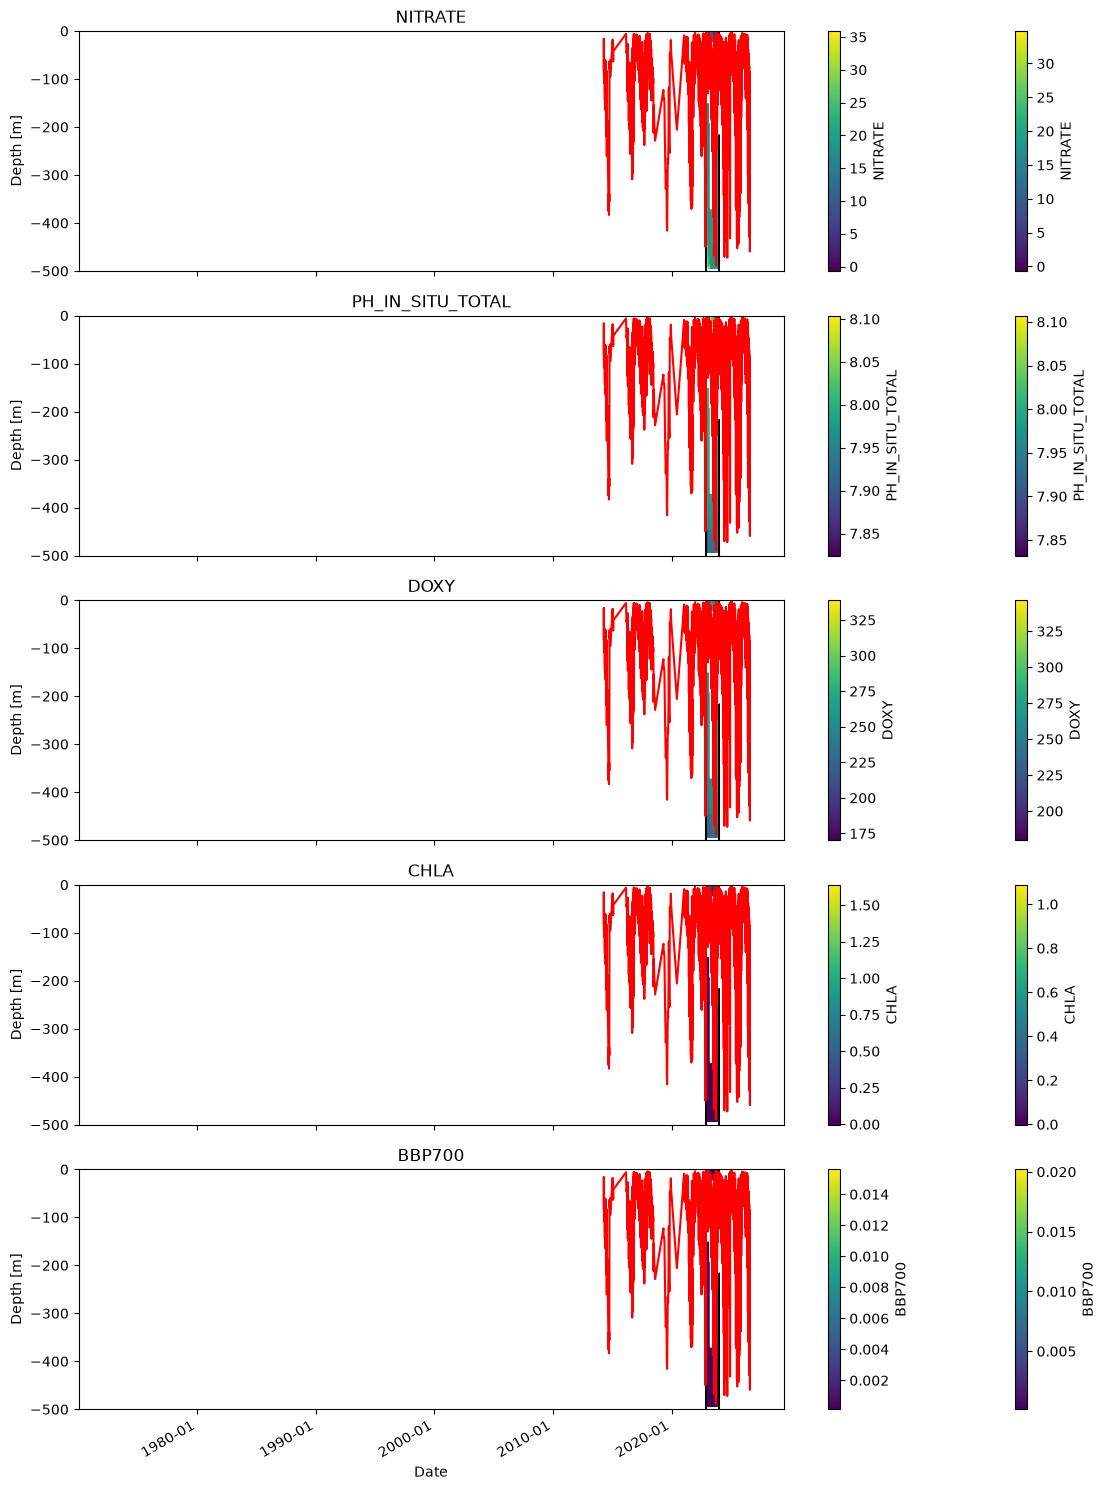

In [33]:
from scipy.interpolate import griddata
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np

plottables = [
    "NITRATE",
    "PH_IN_SITU_TOTAL",
    "DOXY",
    "CHLA",
    "BBP700"
]

fig, axarr = plt.subplots(
    nrows=5,
    figsize=(12, 15),
    sharex=True
)

axarr = axarr.flatten()

for i, ax in enumerate(axarr):

    variable = plottables[i]

    # ----------------------
    # MHW
    # ----------------------
    
    # Only remove NaNs needed for THIS variable
    d = df_mhw[["JULD", "Depth", variable, "MLD", "Nitracline"]].dropna().copy()

    # Convert datetime to matplotlib numeric dates
    x = mdates.date2num(d["JULD"])
    y = d["Depth"].values
    z = d[variable].values

    # Regular interpolation grid
    xi = np.linspace(x.min(), x.max(), 500)
    yi = np.linspace(-500, 0, 250)

    XI, YI = np.meshgrid(xi, yi)

    # Interpolate
    ZI = griddata(
        (x, y),
        z,
        (XI, YI),
        method="linear"
    )

    # Plot
    im = ax.pcolormesh(
        XI,
        YI,
        ZI,
        shading="auto",
        cmap="viridis"
    )

    ax.xaxis_date()
    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%Y-%m")
    )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(variable)

    ax.set_ylabel("Depth [m]")
    ax.set_ylim(-500, 0)
    ax.set_title(variable)

    xx = d['JULD']
    yy = d['Nitracline']
    ax.plot(xx, yy, color = 'white')

    xx = d['JULD']
    yy = d['MLD']
    ax.plot(xx, yy, color = 'red')

    ax.axvline(x.min(), color = 'k')
    ax.axvline(x.max(), color = 'k')

    # ----------------------
    # CLIMATOLOGY
    # ----------------------
    # Only remove NaNs needed for THIS variable
    d = df_clim[["JULD", "Depth", variable, "MLD", "Nitracline"]].dropna().copy()

    # Convert datetime to matplotlib numeric dates
    x = mdates.date2num(d["JULD"])
    y = d["Depth"].values
    z = d[variable].values

    # Regular interpolation grid
    xi = np.linspace(x.min(), x.max(), 500)
    yi = np.linspace(-500, 0, 250)

    XI, YI = np.meshgrid(xi, yi)

    # Interpolate
    ZI = griddata(
        (x, y),
        z,
        (XI, YI),
        method="linear"
    )

    # Plot
    im = ax.pcolormesh(
        XI,
        YI,
        ZI,
        shading="auto",
        cmap="viridis"
    )

    ax.xaxis_date()
    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%Y-%m")
    )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(variable)

    ax.set_ylabel("Depth [m]")
    ax.set_ylim(-500, 0)
    ax.set_title(variable)

    xx = d['JULD']
    yy = d['Nitracline']
    ax.plot(xx, yy, color = 'white')

    xx = d['JULD']
    yy = d['MLD']
    ax.plot(xx, yy, color = 'red')

axarr[-1].set_xlabel("Date")

fig.autofmt_xdate()
plt.tight_layout()

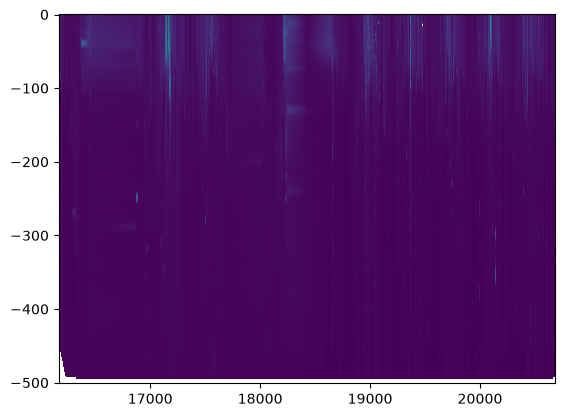

In [35]:
plt.pcolormesh(XI,YI,ZI)

In [67]:
def integrate_over_variable_depth(
    group,
    variable='CHLA_ADJUSTED',
    min_depth=0,
    max_depth=200
):
    """
    Integrate over the available portion of the requested depth interval.

    min_depth and max_depth can each be:
      - numeric constants, e.g. 0, 20, 200
      - column names, e.g. 'MLD'

    The requested interval is clipped to the range where valid data exist.

    Assumes:
      - dataframe Depth is negative downward
      - depth limits are interpreted as positive-down meters
    """

    # --------------------------------
    # Requested minimum depth
    # --------------------------------
    if isinstance(min_depth, str):
        requested_zmin = group[min_depth].iloc[0]
    else:
        requested_zmin = min_depth

    # --------------------------------
    # Requested maximum depth
    # --------------------------------
    if isinstance(max_depth, str):
        requested_zmax = group[max_depth].iloc[0]
    else:
        requested_zmax = max_depth

    if pd.isna(requested_zmin) or pd.isna(requested_zmax):
        return np.nan

    requested_zmin = abs(float(requested_zmin))
    requested_zmax = abs(float(requested_zmax))

    # Ensure shallow -> deep ordering
    if requested_zmin > requested_zmax:
        requested_zmin, requested_zmax = (
            requested_zmax,
            requested_zmin
        )

    # --------------------------------
    # Valid profile observations
    # --------------------------------
    g = group[['Depth', variable]].dropna().copy()

    if len(g) < 2:
        return np.nan

    # Convert negative-down to positive-down
    g['Depth_positive'] = -g['Depth']

    # Remove values above sea level
    g = g[g['Depth_positive'] >= 0]

    # Average duplicate depths and sort
    g = (
        g[['Depth_positive', variable]]
        .groupby('Depth_positive', as_index=False)
        .mean()
        .sort_values('Depth_positive')
    )

    if len(g) < 2:
        return np.nan

    # --------------------------------
    # Available depth range
    # --------------------------------
    shallowest_available = g['Depth_positive'].min()
    deepest_available = g['Depth_positive'].max()

    # Clip requested integration interval
    # to actual available data
    zmin = max(
        requested_zmin,
        shallowest_available
    )

    zmax = min(
        requested_zmax,
        deepest_available
    )

    # No overlap between requested interval and data
    if zmax <= zmin:
        return np.nan

    # --------------------------------
    # Interpolate at exact boundaries
    # --------------------------------
    value_min = np.interp(
        zmin,
        g['Depth_positive'].values,
        g[variable].values
    )

    value_max = np.interp(
        zmax,
        g['Depth_positive'].values,
        g[variable].values
    )

    # Observations inside interval
    g_int = g[
        (g['Depth_positive'] > zmin) &
        (g['Depth_positive'] < zmax)
    ].copy()

    # Add exact boundaries
    boundaries = pd.DataFrame({
        'Depth_positive': [zmin, zmax],
        variable: [value_min, value_max]
    })

    g_int = (
        pd.concat(
            [boundaries, g_int],
            ignore_index=True
        )
        .sort_values('Depth_positive')
    )

    if len(g_int) < 2:
        return np.nan

    return np.trapezoid(
        g_int[variable].values,
        x=g_int['Depth_positive'].values
    )

In [72]:
df5 = df5.merge(
    nitrate_threshold_depth,
    on=["JULD", "PLATFORM_NUMBER", "CYCLE_NUMBER"],
    how="left"
)

df5 = df5.merge(
    density_threshold_depth,
    on=["JULD", "PLATFORM_NUMBER", "CYCLE_NUMBER"],
    how="left"
)
df5

,JULD,PRES,PLATFORM_NUMBER,CYCLE_NUMBER,TEMP,PSAL,DOXY,BBP,BBP470,BBP532,...,BBP532_RAW,LATITUDE,LONGITUDE,CHLA_DCM,BBP700_DBM,Week,Depth,sigma0,nitrate_threshold_depth,density_threshold_depth
0,2022-11-17 22:33:08.000000000,0.0,5906624.0,150.0,4.401000,34.029083,315.228149,NaN,NaN,NaN,...,NaN,-57.961764,178.788691,0.137638,0.001282,46.0,0.000000,26.972647,-164.396287,-51.511862
1,2022-11-17 22:33:08.000000000,1.0,5906624.0,150.0,4.399428,34.029785,315.328156,NaN,NaN,NaN,...,NaN,-57.961764,178.788691,0.137638,0.001277,46.0,-0.990735,26.973380,-164.396287,-51.511862
2,2022-11-17 22:33:08.000000000,2.0,5906624.0,150.0,4.391571,34.033295,315.323120,NaN,NaN,NaN,...,NaN,-57.961764,178.788691,0.137638,0.001277,46.0,-1.981466,26.977016,-164.396287,-51.511862
3,2022-11-17 22:33:08.000000000,3.0,5906624.0,150.0,4.390000,34.033892,315.344914,NaN,NaN,NaN,...,NaN,-57.961764,178.788691,0.137638,0.001274,46.0,-2.972192,26.977666,-164.396287,-51.511862
4,2022-11-17 22:33:08.000000000,4.0,5906624.0,150.0,4.389500,34.032997,315.426956,NaN,NaN,NaN,...,NaN,-57.961764,178.788691,0.137638,0.001267,46.0,-3.962913,26.977018,-164.396287,-51.511862
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162820,2023-12-29 21:25:44.002289152,496.0,5906546.0,39.0,6.497620,34.310142,NaN,NaN,NaN,NaN,...,NaN,-52.580900,-151.169500,NaN,NaN,52.0,-491.045192,26.951662,-81.262084,-66.399484
162821,2023-12-29 21:25:44.002289152,497.0,5906546.0,39.0,6.493445,34.309872,NaN,NaN,NaN,NaN,...,NaN,-52.580900,-151.169500,NaN,NaN,52.0,-492.034018,26.952010,-81.262084,-66.399484
162822,2023-12-29 21:25:44.002289152,498.0,5906546.0,39.0,6.489945,34.309872,NaN,NaN,NaN,NaN,...,NaN,-52.580900,-151.169500,NaN,NaN,52.0,-493.022840,26.952483,-81.262084,-66.399484
162823,2023-12-29 21:25:44.002289152,499.0,5906546.0,39.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-52.580900,-151.169500,NaN,NaN,52.0,-494.011657,NaN,-81.262084,-66.399484


In [75]:
chla_integrated_nitracline = (
    df5
    .groupby(['JULD', 'PLATFORM_NUMBER', 'CYCLE_NUMBER'])
    .apply(
        integrate_over_variable_depth,
        variable='CHLA',
        min_depth=0,
        max_depth='nitrate_threshold_depth')
    .reset_index(name='CHLA_integrated')
)

chla_integrated_MLD = (
    df5
    .groupby(['JULD', 'PLATFORM_NUMBER', 'CYCLE_NUMBER'])
    .apply(
        integrate_over_variable_depth,
        variable='CHLA',
        min_depth=0,
        max_depth='density_threshold_depth')
    .reset_index(name='CHLA_integrated')
)

bbp_integrated_nitracline = (
    df5
    .groupby(['JULD', 'PLATFORM_NUMBER', 'CYCLE_NUMBER'])
    .apply(
        integrate_over_variable_depth,
        variable='BBP700',
        min_depth=0,
        max_depth='nitrate_threshold_depth')
    .reset_index(name='BBP700_integrated')
)

bbp_integrated_MLD = (
    df5
    .groupby(['JULD', 'PLATFORM_NUMBER', 'CYCLE_NUMBER'])
    .apply(
        integrate_over_variable_depth,
        variable='BBP700',
        min_depth=0,
        max_depth='density_threshold_depth')
    .reset_index(name='BBP700_integrated')
)

chla_integrated_200 = (
    df5
    .groupby(['JULD', 'PLATFORM_NUMBER', 'CYCLE_NUMBER'])
    .apply(
        integrate_over_variable_depth,
        variable='CHLA',
        min_depth=0,
        max_depth=200)
    .reset_index(name='CHLA_integrated')
)

bbp_integrated_200 = (
    df5
    .groupby(['JULD', 'PLATFORM_NUMBER', 'CYCLE_NUMBER'])
    .apply(
        integrate_over_variable_depth,
        variable='BBP700',
        min_depth=0,
        max_depth=200)
    .reset_index(name='BBP700_integrated')
)

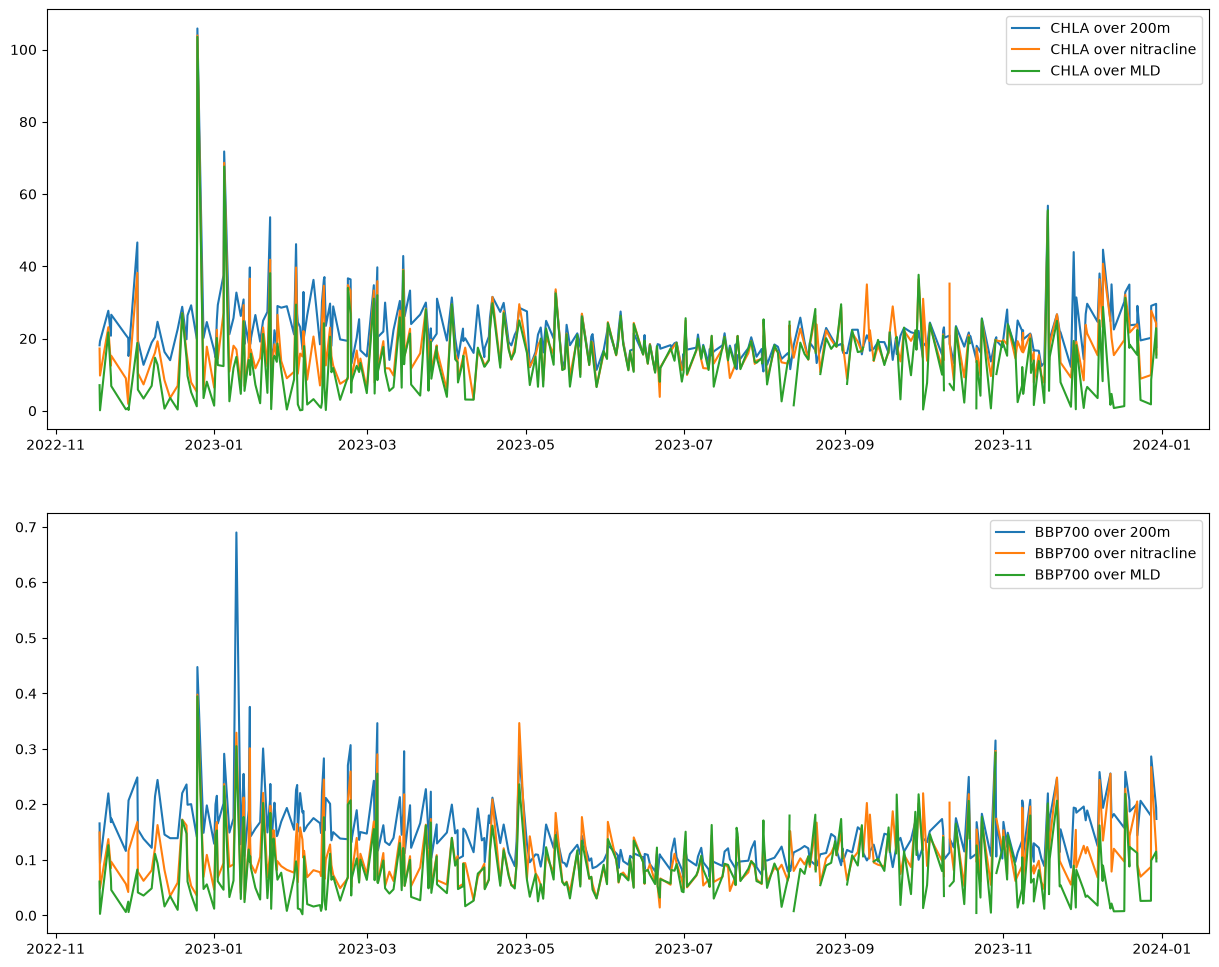

In [83]:
fig, axarr = plt.subplots(nrows = 2, figsize = [15,12])
axarr = axarr.flatten()

ax = axarr[0]

x = chla_integrated_200['JULD']
y = chla_integrated_200["CHLA_integrated"]
ax.plot(x, y, label = "CHLA over 200m")

x = chla_integrated_nitracline['JULD']
y = chla_integrated_nitracline["CHLA_integrated"]
ax.plot(x, y, label = "CHLA over nitracline")

x = chla_integrated_MLD['JULD']
y = chla_integrated_MLD["CHLA_integrated"]
ax.plot(x, y, label = "CHLA over MLD")

ax.legend()

ax = axarr[1]

x = bbp_integrated_200['JULD']
y = bbp_integrated_200["BBP700_integrated"]
ax.plot(x, y, label = "BBP700 over 200m")

x = bbp_integrated_nitracline['JULD']
y = bbp_integrated_nitracline["BBP700_integrated"]
ax.plot(x, y, label = "BBP700 over nitracline")

x = bbp_integrated_MLD['JULD']
y = bbp_integrated_MLD["BBP700_integrated"]
ax.plot(x, y, label = "BBP700 over MLD")

ax.legend()